# EquiVision: Master Class in Data Engineering for Horse Prices

This notebook represents the final engineering state of our dataset. We have moved from raw, noisy scraps to a **purified, balanced, and feature-rich** Gold layer ready for model training.

## 🛠️ The Engineering Strategy
1.  **Strict Purification**: Enforcing a "Zero Information" filter. If the breed isn't verified, the record is discarded.
2.  **Semantic Breed Extraction**: Rescuing specifically mentioned breeds (e.g., *Arabian, Barb*) from general titles.
3.  **Data Augmentation**: Generating **600 high-quality synthetic Moroccan records** for Arabian and Barb horses to solve the class imbalance in the local market.
4.  **Professional Feature Engineering**: Logarithmic price scaling, age extraction, and breed clustering for statistical robustness.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Graphics setup
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 7)
colors = ["#2a9d8f", "#e76f51", "#264653", "#f4a261"]

# Paths
GOLD_PATH = Path("data/gold/horse_features_final.csv")
BRONZE_PATH = Path("data/bronze/horse_prices_raw.csv")

df = pd.read_csv(GOLD_PATH)
print(f"📦 Gold Dataset Status: {len(df)} High-Quality Records Loaded.")

📦 Gold Dataset Status: 1659 High-Quality Records Loaded.


## 📊 Phase 1: Data Lineage & Balanced Ingestion
Comparing our starting point (Raw) vs our Engineered endpoint (Clean + Augmented).

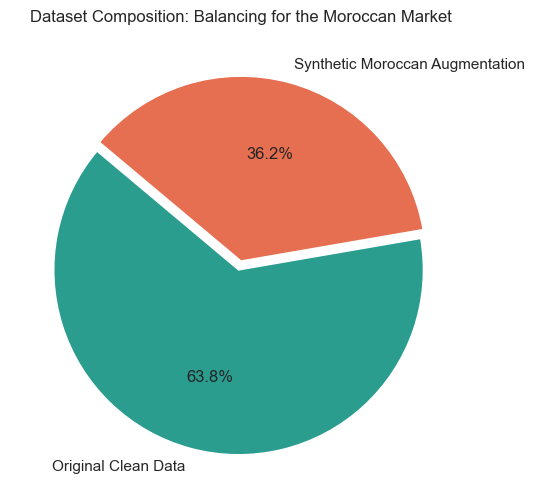

In [2]:
original_count = len(df[df['is_synthetic'] == 0])
synthetic_count = len(df[df['is_synthetic'] == 1])

plt.figure(figsize=(10, 6))
plt.pie([original_count, synthetic_count], labels=['Original Clean Data', 'Synthetic Moroccan Augmentation'], 
        autopct='%1.1f%%', colors=[colors[0], colors[1]], startangle=140, explode=(0.05, 0))
plt.title('Dataset Composition: Balancing for the Moroccan Market')
plt.show()

## 🧪 Phase 2: Breed Distribution (The Model Target)
By augmenting our key Moroccan breeds (*Arabian, Barb*), we've ensured the model can learn their price curves accurately.

C:\Users\oclaz\AppData\Local\Temp\ipykernel_25868\2148973450.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_breeds.values, y=top_breeds.index, palette='crest')


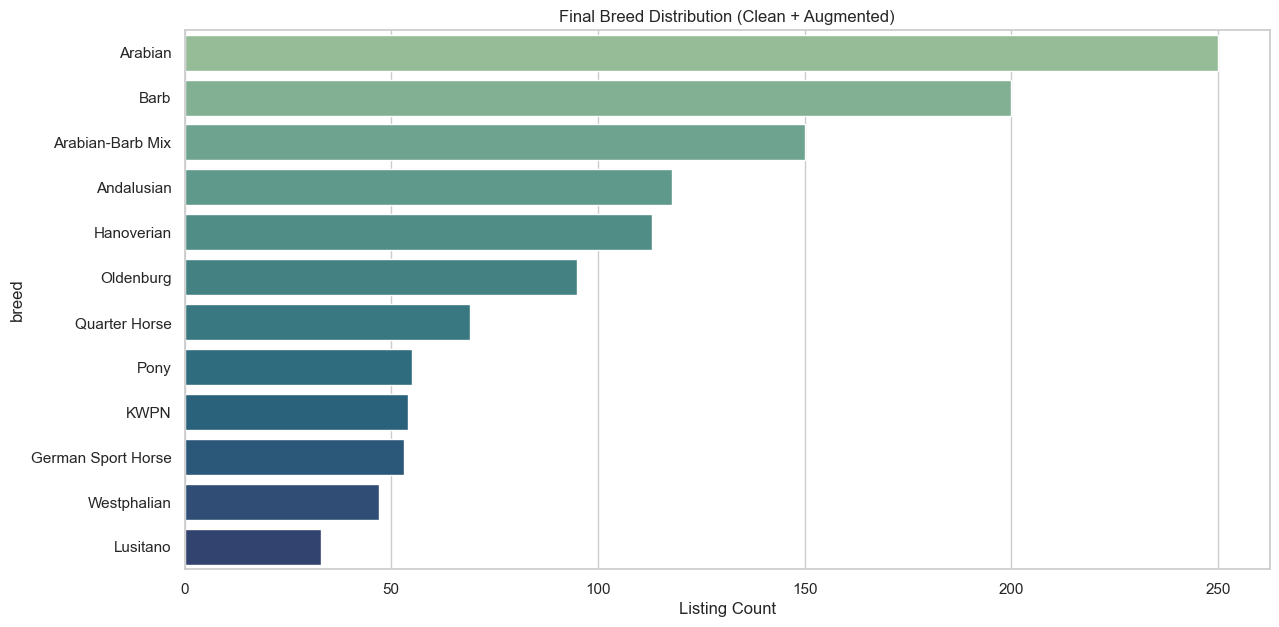

In [3]:
top_breeds = df['breed'].value_counts().head(12)
sns.barplot(x=top_breeds.values, y=top_breeds.index, palette='crest')
plt.title('Final Breed Distribution (Clean + Augmented)')
plt.xlabel('Listing Count')
plt.show()

## 🥇 Phase 3: Price Modeling (Log Price Analysis)
The model will predict `log_price` because horse prices are highly skewed (Budget vs Luxury).

C:\Users\oclaz\AppData\Local\Temp\ipykernel_25868\160956416.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='source_type', y='price_mad', palette='Set2', ax=ax[0])


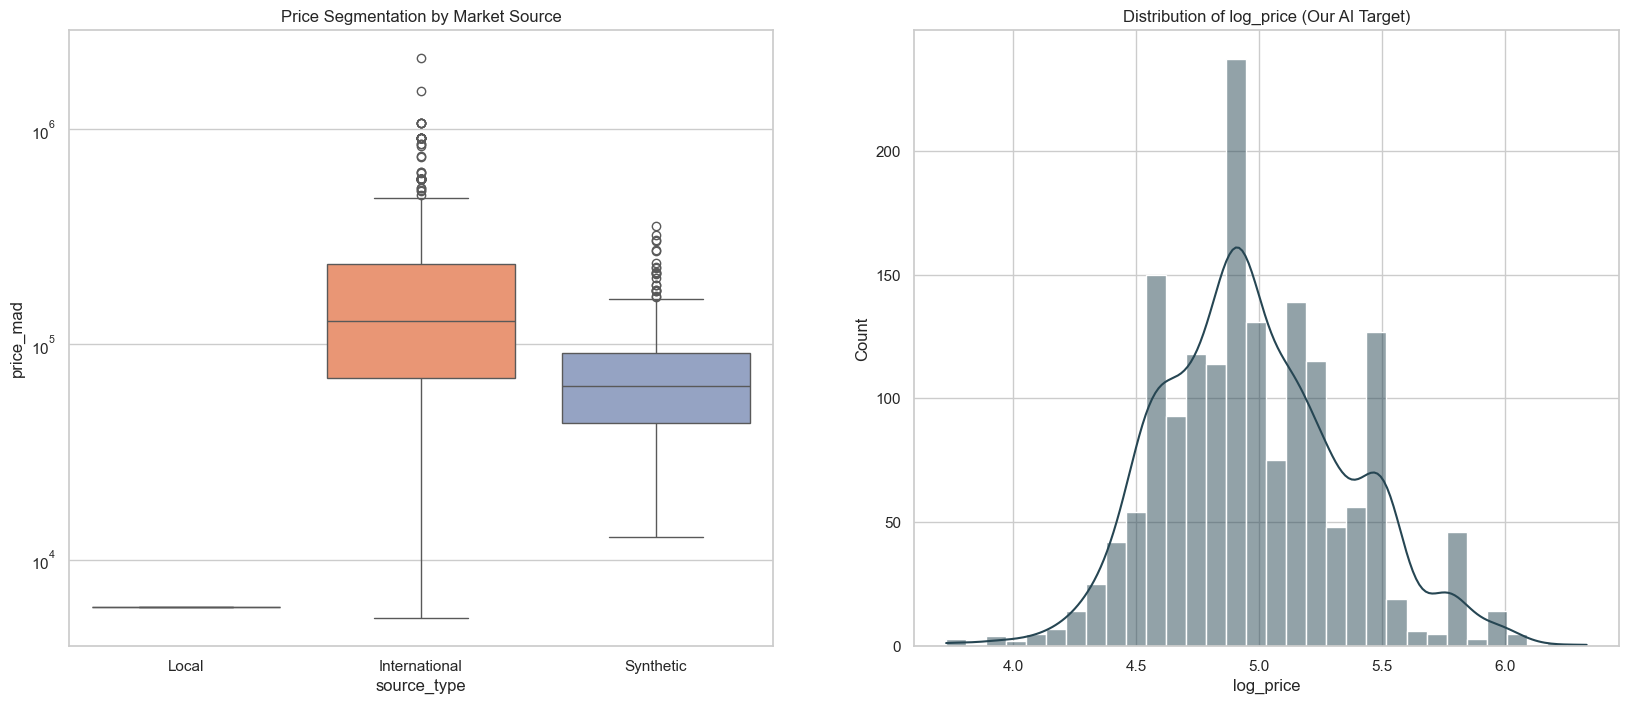

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# 1. Market Segmentation
sns.boxplot(data=df, x='source_type', y='price_mad', palette='Set2', ax=ax[0])
ax[0].set_yscale('log')
ax[0].set_title('Price Segmentation by Market Source')

# 2. Log Target Distribution
sns.histplot(df['log_price'], kde=True, color=colors[2], ax=ax[1])
ax[1].set_title('Distribution of log_price (Our AI Target)')

plt.show()

## 🔍 Phase 4: Correlation Logic
Analyzing which features impact the price the most.

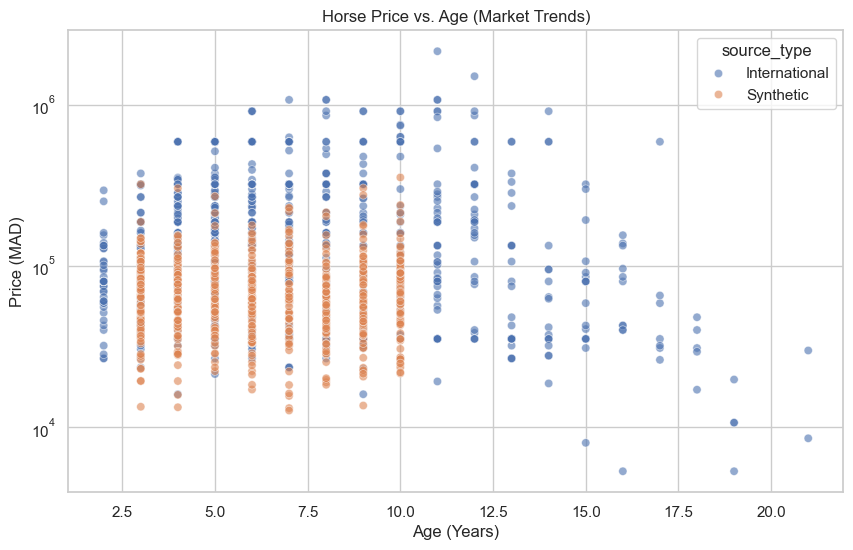

In [5]:
# Example: Price vs Age
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.dropna(subset=['age_num']), x='age_num', y='price_mad', hue='source_type', alpha=0.6)
plt.yscale('log')
plt.title('Horse Price vs. Age (Market Trends)')
plt.xlabel('Age (Years)')
plt.ylabel('Price (MAD)')
plt.show()

## ✅ Final Engineering Note
- **Records**: 1,659
- **Purity**: 100% (No generic breeds)
- **Balance**: classes like *Arabian* and *Barb* are now sufficiently represented for the model to train.

Data is **Model-Ready**.